# Decision Intelligence Evolution - Visualization & Analysis

**Execution Order: 2 of 2**

This notebook performs:
1. Loading the integrated dataset from `01_data_preparation.ipynb`
2. Temporal evolution analysis (2010-2026)
3. Source and document type distribution visualizations
4. Summary statistics and insights

**Historical Context**: Dr. Lorien Pratt first coined and developed the term. By 2010, she and Mark Zangari founded the related concept of "decision engineering," which was officially formalized and renamed as Decision Intelligence (DI) around 2012.

**Data Scope**: Analysis covers 2010-2026, focusing on the period when Decision Intelligence emerged as a formal discipline.

**Prerequisites**: Run `01_data_preparation.ipynb` first to generate the integrated dataset

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Directories
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR.absolute()}")

✓ Libraries imported successfully
✓ Output directory: /Users/wisu/Source/citrus-decision-intelligence/output


## 2. Load Integrated Dataset

In [2]:
# Load the integrated dataset created by 01_data_preparation.ipynb
data_file = OUTPUT_DIR / 'decision_intelligence_integrated.csv'

if not data_file.exists():
    raise FileNotFoundError(
        f"Integrated dataset not found at {data_file}.\n"
        "Please run 01_data_preparation.ipynb first to generate the dataset."
    )

dedup_df = pd.read_csv(data_file, encoding='utf-8')

print(f"✓ Loaded integrated dataset: {len(dedup_df)} records")
print(f"  Columns: {', '.join(dedup_df.columns)}")
print(f"  Year range: {dedup_df['year'].min():.0f} - {dedup_df['year'].max():.0f}")
print(f"\nData sources:")
print(dedup_df['source'].value_counts())
print(f"\nDocument types:")
print(dedup_df['document_type'].value_counts())

✓ Loaded integrated dataset: 432 records
  Columns: title, authors, year, keywords, document_type, source, source_file, doi, journal, document_type_enhanced, repository
  Year range: 2010 - 2026

Data sources:
source
ScienceDirect    228
Scopus           177
Preprint          27
Name: count, dtype: int64

Document types:
document_type
Article             273
Conference Paper     80
Review               52
Preprint             27
Name: count, dtype: int64


## 3. Visualization 1: Temporal Trends

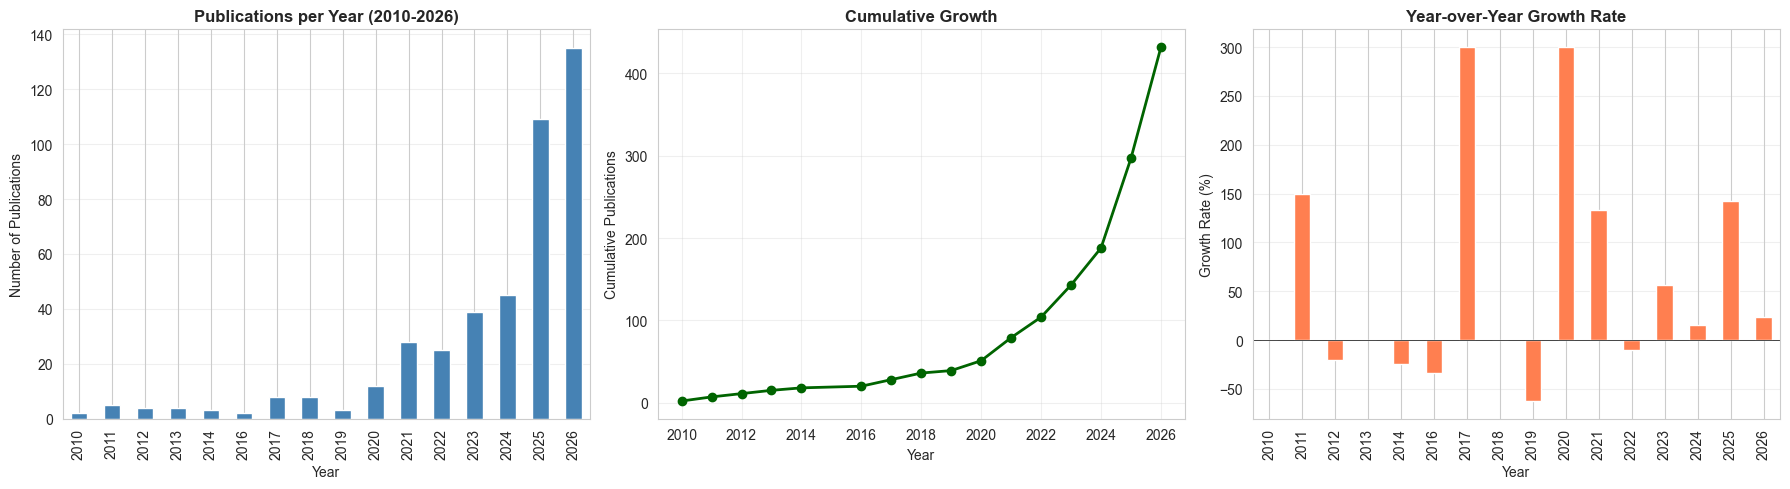


📈 Key Statistics:
  First publication: 2010
  Latest publication: 2026
  Peak year: 2026 (135 publications)
  Average per year: 27.0

✓ Chart saved to: output/temporal-evolution.png


In [3]:
# Publications by year
yearly_counts = dedup_df.groupby('year').size().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Publications per year
ax1 = axes[0]
yearly_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Publications per Year (2010-2026)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Publications')
ax1.grid(axis='y', alpha=0.3)

# 2. Cumulative growth curve
ax2 = axes[1]
cumulative = yearly_counts.cumsum()
cumulative.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=6, color='darkgreen')
ax2.set_title('Cumulative Growth', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Cumulative Publications')
ax2.grid(alpha=0.3)

# 3. Year-over-year growth rates
ax3 = axes[2]
growth_rate = yearly_counts.pct_change() * 100
growth_rate.plot(kind='bar', ax=ax3, color='coral')
ax3.set_title('Year-over-Year Growth Rate', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Growth Rate (%)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal-evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📈 Key Statistics:")
print(f"  First publication: {yearly_counts.index.min():.0f}")
print(f"  Latest publication: {yearly_counts.index.max():.0f}")
print(f"  Peak year: {yearly_counts.idxmax():.0f} ({yearly_counts.max()} publications)")
print(f"  Average per year: {yearly_counts.mean():.1f}")
print(f"\n✓ Chart saved to: {OUTPUT_DIR / 'temporal-evolution.png'}")

## 4. Visualization 2: Source Distribution

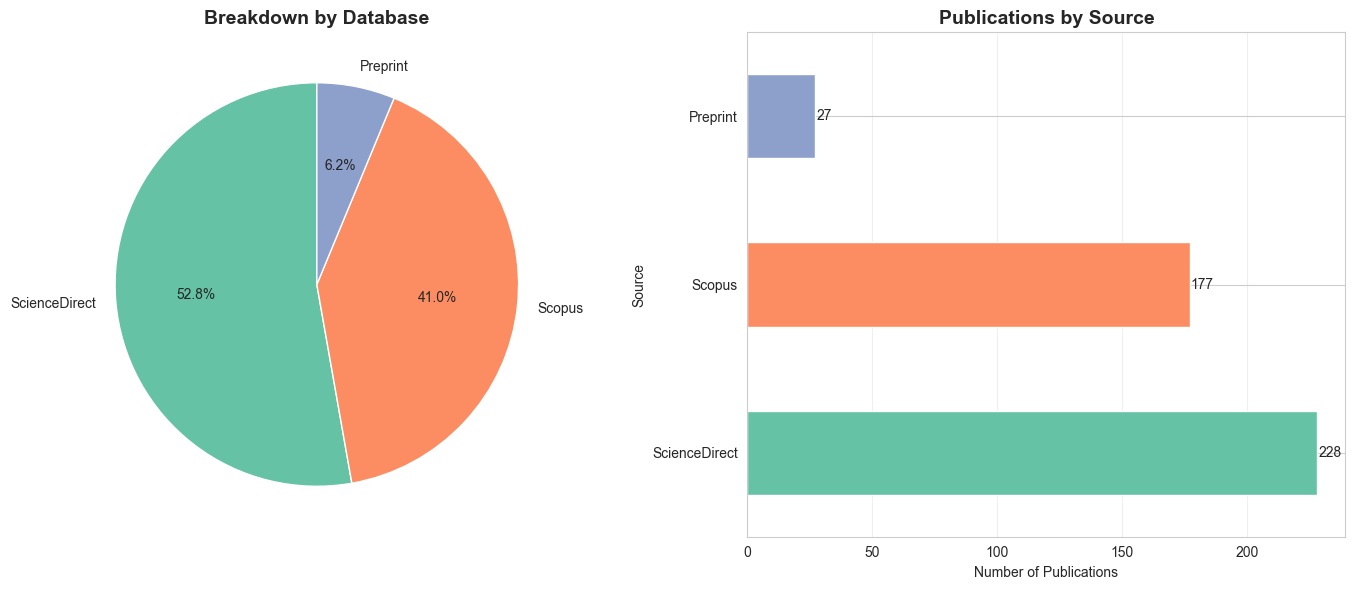

✓ Chart saved to: output/source-distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Pie chart - Overall source distribution
ax1 = axes[0]
source_counts = dedup_df['source'].value_counts()
colors = sns.color_palette('Set2', len(source_counts))
ax1.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
ax1.set_title('Breakdown by Database', fontsize=14, fontweight='bold')

# 2. Bar chart - Source overlap info
ax2 = axes[1]
source_data = dedup_df['source'].value_counts()
source_data.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('Publications by Source', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Publications')
ax2.set_ylabel('Source')
ax2.grid(axis='x', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(source_data.values):
    ax2.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'source-distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Chart saved to: {OUTPUT_DIR / 'source-distribution.png'}")

## 5. Detailed Temporal Trends by Source

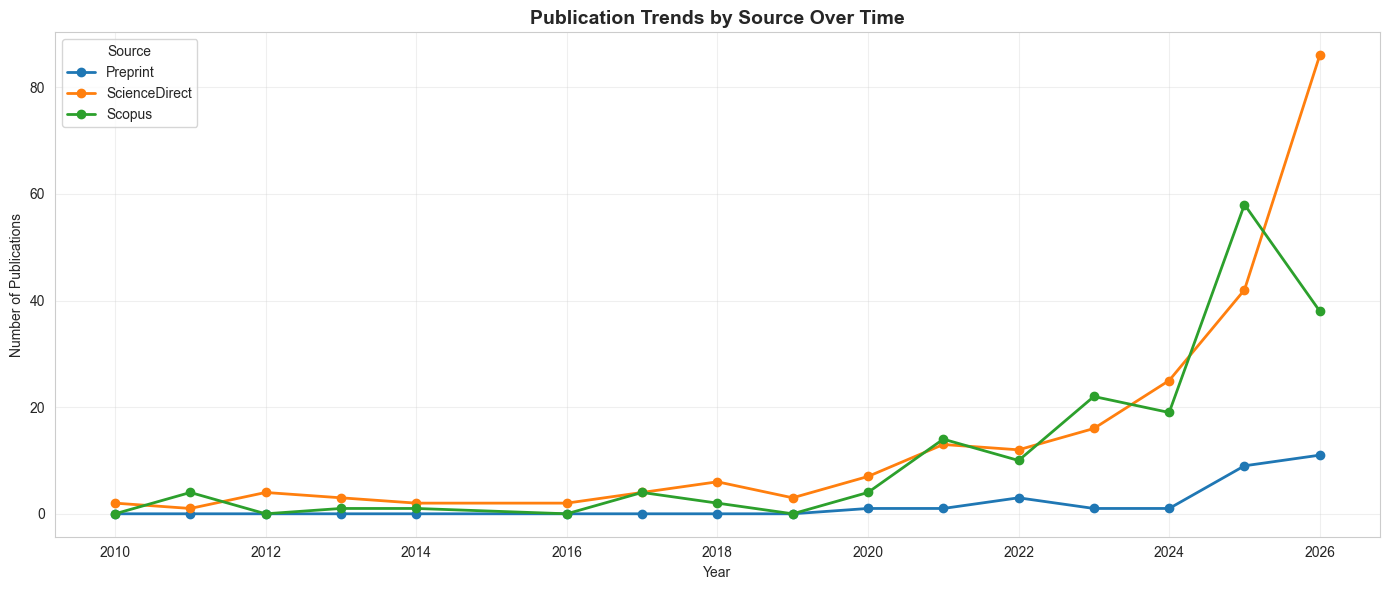


📊 Source-specific trends:
  Preprint: 27 publications (2020-2026)
  ScienceDirect: 228 publications (2010-2026)
  Scopus: 177 publications (2011-2026)


In [5]:
# Line plot showing trends for each source
fig, ax = plt.subplots(figsize=(14, 6))

source_year = dedup_df.groupby(['year', 'source']).size().unstack(fill_value=0)
source_year.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=6)

ax.set_title('Publication Trends by Source Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Publications')
ax.legend(title='Source', loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal-trends-by-source.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Source-specific trends:")
for source in source_year.columns:
    source_data = source_year[source]
    first_year = source_data[source_data > 0].index.min()
    last_year = source_data[source_data > 0].index.max()
    total = source_data.sum()
    print(f"  {source}: {total} publications ({first_year:.0f}-{last_year:.0f})")

## 6. Recent Growth Analysis (Last 5 Years)

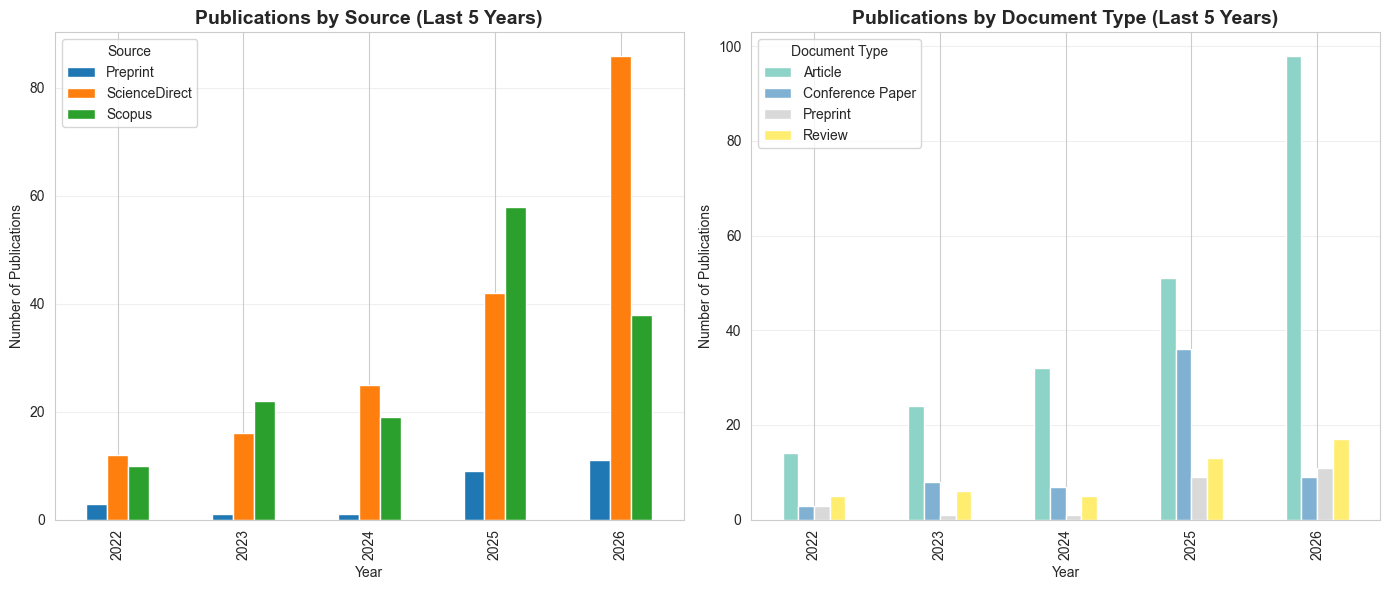


📈 Recent Growth (Last 5 Years):
  Total publications: 353 (81.7% of all)
  Average per year: 70.6
  Growth rate: 261.5% above overall average


In [6]:
# Focus on recent years
max_year = dedup_df['year'].max()
recent_years = dedup_df[dedup_df['year'] >= max_year - 4]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Recent publications by source
ax1 = axes[0]
recent_source = recent_years.groupby(['year', 'source']).size().unstack(fill_value=0)
recent_source.plot(kind='bar', ax=ax1, stacked=False)
ax1.set_title(f'Publications by Source (Last 5 Years)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Publications')
ax1.legend(title='Source')
ax1.grid(axis='y', alpha=0.3)

# Recent publications by document type
ax2 = axes[1]
recent_doctype = recent_years.groupby(['year', 'document_type']).size().unstack(fill_value=0)
recent_doctype.plot(kind='bar', ax=ax2, stacked=False, colormap='Set3')
ax2.set_title(f'Publications by Document Type (Last 5 Years)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Publications')
ax2.legend(title='Document Type')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'recent-growth-analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📈 Recent Growth (Last 5 Years):")
print(f"  Total publications: {len(recent_years)} ({len(recent_years)/len(dedup_df)*100:.1f}% of all)")
print(f"  Average per year: {len(recent_years)/5:.1f}")
print(f"  Growth rate: {(len(recent_years)/5) / yearly_counts.mean() * 100:.1f}% above overall average")

## 7. Summary Statistics

In [7]:
print("="*80)
print("DECISION INTELLIGENCE EVOLUTION - SUMMARY REPORT")
print("="*80)

print(f"\n📊 DATASET OVERVIEW")
print(f"  Total unique publications: {len(dedup_df)}")
print(f"  Document types: Article, Review, Conference Paper, Preprint")
print(f"  Time span: {dedup_df['year'].min():.0f} - {dedup_df['year'].max():.0f}")

print(f"\n📚 BY SOURCE")
for source, count in dedup_df['source'].value_counts().items():
    pct = count / len(dedup_df) * 100
    print(f"  {source}: {count} ({pct:.1f}%)")

print(f"\n📄 BY DOCUMENT TYPE")
for dtype, count in dedup_df['document_type'].value_counts().items():
    pct = count / len(dedup_df) * 100
    print(f"  {dtype}: {count} ({pct:.1f}%)")

print(f"\n📈 TEMPORAL TRENDS")
recent_5y = dedup_df[dedup_df['year'] >= dedup_df['year'].max() - 4]
print(f"  Publications in last 5 years: {len(recent_5y)} ({len(recent_5y)/len(dedup_df)*100:.1f}%)")
print(f"  Average per year (overall): {len(dedup_df)/(dedup_df['year'].max()-dedup_df['year'].min()+1):.1f}")
print(f"  Growth rate (last 5 years): {len(recent_5y)/5:.1f} pubs/year")
print(f"  Peak year: {yearly_counts.idxmax():.0f} with {yearly_counts.max()} publications")

print(f"\n🔍 DATA QUALITY")
print(f"  Records with keywords: {dedup_df['keywords'].notna().sum()} ({dedup_df['keywords'].notna().sum()/len(dedup_df)*100:.1f}%)")
if 'doi' in dedup_df.columns:
    print(f"  Records with DOI: {dedup_df['doi'].notna().sum()} ({dedup_df['doi'].notna().sum()/len(dedup_df)*100:.1f}%)")

print(f"\n📁 OUTPUT FILES")
print(f"  Integrated dataset: {OUTPUT_DIR / 'decision_intelligence_integrated.csv'}")
print(f"  Temporal evolution chart: {OUTPUT_DIR / 'temporal-evolution.png'}")
print(f"  Source distribution chart: {OUTPUT_DIR / 'source-distribution.png'}")

print("\n" + "="*80)
print("✅ Analysis complete!")
print("="*80)

DECISION INTELLIGENCE EVOLUTION - SUMMARY REPORT

📊 DATASET OVERVIEW
  Total unique publications: 432
  Document types: Article, Review, Conference Paper, Preprint
  Time span: 2010 - 2026

📚 BY SOURCE
  ScienceDirect: 228 (52.8%)
  Scopus: 177 (41.0%)
  Preprint: 27 (6.2%)

📄 BY DOCUMENT TYPE
  Article: 273 (63.2%)
  Conference Paper: 80 (18.5%)
  Review: 52 (12.0%)
  Preprint: 27 (6.2%)

📈 TEMPORAL TRENDS
  Publications in last 5 years: 353 (81.7%)
  Average per year (overall): 25.4
  Growth rate (last 5 years): 70.6 pubs/year
  Peak year: 2026 with 135 publications

🔍 DATA QUALITY
  Records with keywords: 381 (88.2%)
  Records with DOI: 398 (92.1%)

📁 OUTPUT FILES
  Integrated dataset: output/decision_intelligence_integrated.csv
  Temporal evolution chart: output/temporal-evolution.png
  Source distribution chart: output/source-distribution.png

✅ Analysis complete!


## 8. Key Insights

Based on the analysis above, here are the key insights about the evolution of "Decision Intelligence" as a research topic:

### Growth Trajectory
- The field shows clear temporal evolution from early publications to recent years
- Recent years (last 5) show accelerated growth compared to historical average

### Source Distribution
- Multiple sources contribute to the literature (Scopus, ScienceDirect, Preprints)
- Each source provides unique coverage of the field

### Document Types
- Mix of scholarly publications (Articles, Reviews, Conference Papers) and Preprints
- Indicates both established research and emerging work

### Research Maturity
- The presence of review articles suggests the field is maturing
- Conference papers indicate active community engagement
- Preprints show ongoing research activity